In [5]:
import pandas as pd

df = pd.read_csv("KDDTest+.txt", header=None)

df.shape
df.head()

,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,0,tcp,private,REJ,0,0,0,0,0,0,...,0.04,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
1,0,tcp,private,REJ,0,0,0,0,0,0,...,0.00,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.61,0.04,0.61,0.02,0.0,0.0,0.00,0.00,normal,21
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,1.00,0.00,1.00,0.28,0.0,0.0,0.00,0.00,saint,15
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.31,0.17,0.03,0.02,0.0,0.0,0.83,0.71,mscan,11


In [6]:
df[41].value_counts()


41
normal             9711
neptune            4657
guess_passwd       1231
mscan               996
warezmaster         944
apache2             737
satan               735
processtable        685
smurf               665
back                359
snmpguess           331
saint               319
mailbomb            293
snmpgetattack       178
portsweep           157
ipsweep             141
httptunnel          133
nmap                 73
pod                  41
buffer_overflow      20
multihop             18
named                17
ps                   15
sendmail             14
rootkit              13
xterm                13
teardrop             12
xlock                 9
land                  7
xsnoop                4
ftp_write             3
worm                  2
loadmodule            2
perl                  2
sqlattack             2
udpstorm              2
phf                   2
imap                  1
Name: count, dtype: int64

In [7]:
df = df.drop_duplicates()

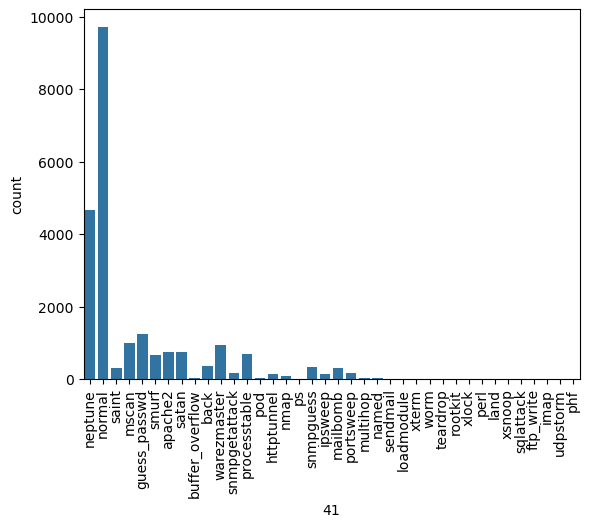

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df[41])
plt.xticks(rotation=90)
plt.show()

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [11]:
df = pd.read_csv("KDDTest+.txt", header=None)

print(df.shape)
df.head()

(22544, 43)


,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,0,tcp,private,REJ,0,0,0,0,0,0,...,0.04,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
1,0,tcp,private,REJ,0,0,0,0,0,0,...,0.00,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.61,0.04,0.61,0.02,0.0,0.0,0.00,0.00,normal,21
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,1.00,0.00,1.00,0.28,0.0,0.0,0.00,0.00,saint,15
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.31,0.17,0.03,0.02,0.0,0.0,0.83,0.71,mscan,11


In [13]:
columns = [
'duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
'wrong_fragment','urgent','hot','num_failed_logins','logged_in',
'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
'num_shells','num_access_files','num_outbound_cmds','is_host_login',
'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
'dst_host_same_srv_rate','dst_host_diff_srv_rate',
'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
'dst_host_serror_rate','dst_host_srv_serror_rate',
'dst_host_rerror_rate','dst_host_srv_rerror_rate','label','difficulty'
]

df.columns = columns

In [14]:
df = df.drop('difficulty', axis=1)

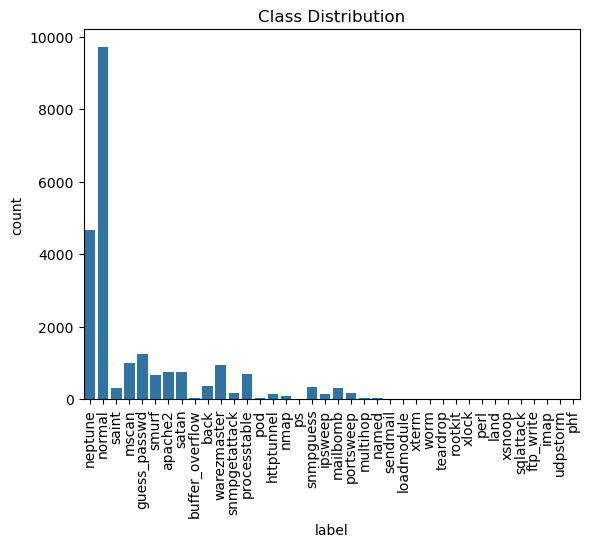

In [15]:
sns.countplot(x=df['label'])
plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.show()

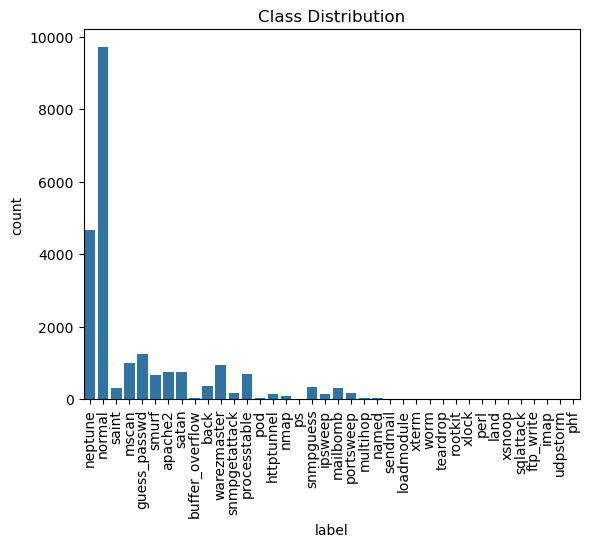

In [16]:
sns.countplot(x=df['label'])
plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.show()

In [17]:
class_counts = df['label'].value_counts()

print(class_counts)

label
normal             9711
neptune            4657
guess_passwd       1231
mscan               996
warezmaster         944
apache2             737
satan               735
processtable        685
smurf               665
back                359
snmpguess           331
saint               319
mailbomb            293
snmpgetattack       178
portsweep           157
ipsweep             141
httptunnel          133
nmap                 73
pod                  41
buffer_overflow      20
multihop             18
named                17
ps                   15
sendmail             14
rootkit              13
xterm                13
teardrop             12
xlock                 9
land                  7
xsnoop                4
ftp_write             3
worm                  2
loadmodule            2
perl                  2
sqlattack             2
udpstorm              2
phf                   2
imap                  1
Name: count, dtype: int64


In [18]:
imbalance_ratio = class_counts.max() / class_counts.min()

print("Imbalance Ratio:", imbalance_ratio)

Imbalance Ratio: 9711.0


In [19]:
total_samples = len(df)

minority_report = (class_counts / total_samples) * 100

print(minority_report)

label
normal             43.075763
neptune            20.657381
guess_passwd        5.460433
mscan               4.418027
warezmaster         4.187367
apache2             3.269163
satan               3.260291
processtable        3.038502
smurf               2.949787
back                1.592441
snmpguess           1.468240
saint               1.415011
mailbomb            1.299681
snmpgetattack       0.789567
portsweep           0.696416
ipsweep             0.625444
httptunnel          0.589957
nmap                0.323811
pod                 0.181867
buffer_overflow     0.088715
multihop            0.079844
named               0.075408
ps                  0.066537
sendmail            0.062101
rootkit             0.057665
xterm               0.057665
teardrop            0.053229
xlock               0.039922
land                0.031050
xsnoop              0.017743
ftp_write           0.013307
worm                0.008872
loadmodule          0.008872
perl                0.008872
sqlattac

In [20]:
categorical_cols = ['protocol_type','service','flag']

encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

In [21]:
df['label'] = LabelEncoder().fit_transform(df['label'])

In [22]:
scaler = MinMaxScaler()

features = df.drop('label', axis=1)

scaled_features = scaler.fit_transform(features)

X = pd.DataFrame(scaled_features, columns=features.columns)
y = df['label']

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (15780, 41)
Test shape: (6764, 41)


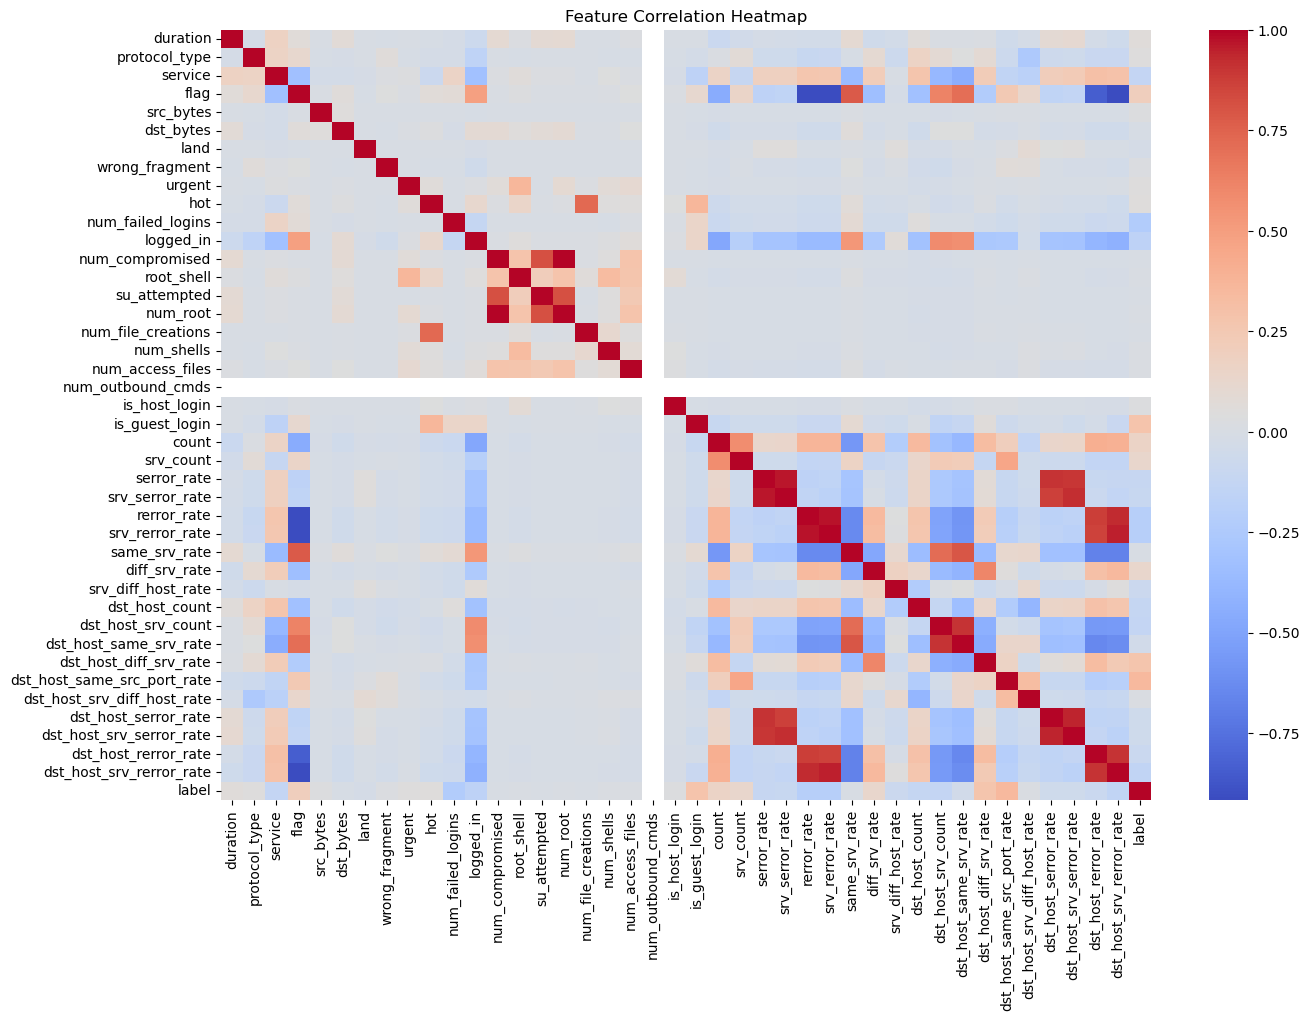

In [24]:
plt.figure(figsize=(15,10))

sns.heatmap(
    df.corr(),
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [25]:
clean_df = pd.concat([X, y], axis=1)

clean_df.to_csv("NSL_KDD_CLEANED.csv", index=False)

In [26]:
class_counts = df['label'].value_counts()

total_samples = len(df)

percentage = (class_counts / total_samples) * 100

report = pd.DataFrame({
    "Class": class_counts.index,
    "Count": class_counts.values,
    "Percentage": percentage.values
})

print(report)

    Class  Count  Percentage
0      16   9711   43.075763
1      14   4657   20.657381
2       4   1231    5.460433
3      11    996    4.418027
4      33    944    4.187367
5       0    737    3.269163
6      25    735    3.260291
7      21    685    3.038502
8      27    665    2.949787
9       1    359    1.592441
10     29    331    1.468240
11     24    319    1.415011
12     10    293    1.299681
13     28    178    0.789567
14     20    157    0.696416
15      7    141    0.625444
16      5    133    0.589957
17     15     73    0.323811
18     19     41    0.181867
19      2     20    0.088715
20     12     18    0.079844
21     13     17    0.075408
22     22     15    0.066537
23     26     14    0.062101
24     23     13    0.057665
25     37     13    0.057665
26     31     12    0.053229
27     35      9    0.039922
28      8      7    0.031050
29     36      4    0.017743
30      3      3    0.013307
31     34      2    0.008872
32      9      2    0.008872
33     17     

In [27]:
cleaned_df = df

cleaned_df.to_csv("NSL_KDD_CLEANED.csv", index=False)

print("Cleaned dataset saved successfully")

Cleaned dataset saved successfully


In [28]:
import os
os.getcwd()

'C:\\Users\\Divyanshi Jha'

In [29]:
import os
os.makedirs("cleaned_data", exist_ok=True)
cleaned_df.to_csv("cleaned_data/NSL_KDD_CLEANED.csv", index=False)